# Excitonic coupling from Coulomb-matrix kernels

The task is to predict the excitonic coupling energy of a molecule pair (A, B) with a kernel model, either Kernel Ridge Regression or Gaussian Process Regression, from Coulomb-matrix representations of the two geometries, and to characterise the result with a learning curve.

`BiMolData/` holds four files: `Coord_A.xyz` and `Coord_B.xyz` with 200 geometries each, `CouplingEnergies.csv` with the coupling energy of every (A, B) pair, and `Coord_supermol.xyz` with the 200x200 pairs treated as single molecules.

In [1]:
import collections
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from ase.io import read as ase_read

DATA = Path("BiMolData")

## Geometries

The xyz files concatenate one block per geometry: an atom count, a comment line, then that many `element x y z` rows. `ase` reads the same file and is used to check the parser.

In [2]:
def parse_xyz(path):
    molecules = []
    lines = Path(path).read_text().splitlines()
    i = 0
    while i < len(lines):
        n = int(lines[i].strip())
        block = lines[i + 2 : i + 2 + n]
        elements = [row.split()[0] for row in block]
        coords = np.array([[float(v) for v in row.split()[1:4]] for row in block])
        molecules.append((elements, coords))
        i += 2 + n
    return molecules


mols_A = parse_xyz(DATA / "Coord_A.xyz")
mols_B = parse_xyz(DATA / "Coord_B.xyz")

ase_A = ase_read(str(DATA / "Coord_A.xyz"), index=":")
assert len(ase_A) == len(mols_A)
assert np.allclose(ase_A[0].get_positions(), mols_A[0][1])

In [3]:
def report(name, mols):
    counts = [len(elements) for elements, _ in mols]
    assert len(set(counts)) == 1
    assert all(elements == mols[0][0] for elements, _ in mols)
    composition = dict(collections.Counter(mols[0][0]))
    print(f"{name}: {len(mols)} molecules, {counts[0]} atoms each")
    print(f"  elements: {sorted(composition)}")
    print(f"  composition: {composition}")


report("A", mols_A)
report("B", mols_B)

A: 200 molecules, 15 atoms each
  elements: ['C', 'H', 'N', 'O']
  composition: {'N': 1, 'O': 3, 'C': 6, 'H': 5}
B: 200 molecules, 15 atoms each
  elements: ['C', 'H', 'N', 'O']
  composition: {'N': 1, 'O': 3, 'C': 6, 'H': 5}


Both sets are 200 molecules of 15 atoms, composition C6H5NO3, and the assertions above also establish that the atom ordering is identical across every geometry. A Coulomb matrix therefore has the same shape and the same row and column meaning for every molecule, and flattens into a fixed-length feature vector with no padding and no sorting step.

## Coupling energies

In [4]:
df = pd.read_csv(DATA / "CouplingEnergies.csv")

assert len(df) == 40000
assert sorted(df["molA"].unique()) == list(range(200))
assert sorted(df["molB"].unique()) == list(range(200))

print(df.head())
print(df["coupling_energy"].describe())

   molA  molB  coupling_energy
0     0     0       -27.740949
1     0     1        -1.924393
2     0     2       -50.196196
3     0     3       -65.963198
4     0     4       -56.458111
count    40000.000000
mean        -1.294752
std         38.406155
min       -116.838094
25%        -29.864116
50%         -0.738620
75%         25.254135
max        108.832597
Name: coupling_energy, dtype: float64


The couplings are roughly symmetric about zero, with a standard deviation of 38.4 and a range of about ±110. The brief quotes a reference MAE of 0.01 to 0.1, three orders of magnitude below that spread. Either the reference is stated in different units, or the target is simply very learnable and a good kernel model reaches a relative error of order 1e-3. Nothing in the data alone decides between the two, so the question stays open until there is a learning curve to compare against. Errors are reported throughout in the units of the CSV.

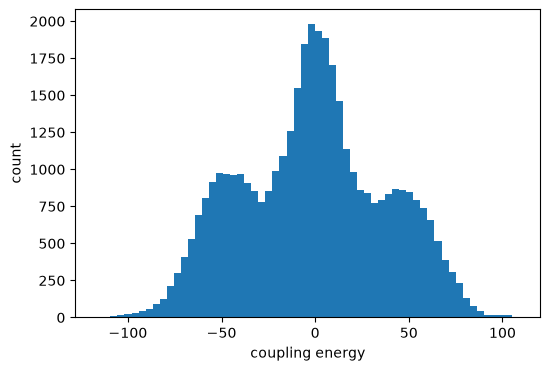

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["coupling_energy"], bins=60)
ax.set_xlabel("coupling energy")
ax.set_ylabel("count")
plt.show()

## Supermolecule geometries

If the pairs had been assembled by placing the two molecules at some relative separation and orientation, that arrangement would itself carry information about the coupling. Comparing supermolecule row `i * 200 + j` against the concatenation of A_i and B_j settles whether it does.

In [6]:
mols_S = parse_xyz(DATA / "Coord_supermol.xyz")
n_A, n_B = len(mols_A[0][0]), len(mols_B[0][0])

assert len(mols_S) == 40000
assert all(len(elements) == n_A + n_B for elements, _ in mols_S)

deviation = 0.0
for i in range(len(mols_A)):
    for j in range(len(mols_B)):
        coords = mols_S[i * len(mols_B) + j][1]
        deviation = max(
            deviation,
            np.abs(coords[:n_A] - mols_A[i][1]).max(),
            np.abs(coords[n_A:] - mols_B[j][1]).max(),
        )

print(f"supermolecules: {len(mols_S)} geometries of {n_A + n_B} atoms")
print(f"max coordinate deviation from concatenated A_i, B_j over all pairs: {deviation:.3g}")

supermolecules: 40000 geometries of 30 atoms
max coordinate deviation from concatenated A_i, B_j over all pairs: 0


Every supermolecule reproduces A_i and B_j exactly, atom for atom, with zero coordinate deviation. Nothing is rotated, translated or displaced when a pair is assembled, so `Coord_supermol.xyz` is a deterministic function of the standalone geometries and holds no information they do not already hold.

That does not make it useless as a representation. A Coulomb matrix built on the supermolecule contains the cross-block Z_i Z_j / |r_i - r_j| between the atoms of A and those of B, an explicit encoding of the pair interaction; reaching the same quantity from the two molecules separately means constructing it by hand. Which of the two to feed the kernel is a modelling decision rather than an information one, and it is the next thing to settle.

## Coulomb-matrix representation

The Coulomb matrix of a geometry is

$$M_{ij} = \begin{cases} \tfrac{1}{2} Z_i^{2.4} & i = j \\[2pt] \dfrac{Z_i Z_j}{\lVert r_i - r_j \rVert} & i \neq j \end{cases}$$

The usual recipe then sorts the rows by norm, or takes the eigenvalue spectrum, to make the descriptor invariant to the order in which atoms happen to be listed. Neither is needed here: the assertions above establish that all 400 monomers carry the same 15 atoms in the same order, so row `k` already means the same atom in every geometry. Sorting would only destroy that correspondence.

The diagonal is worth a second look. It depends on nothing but the element identities, and those are fixed by the constant composition and ordering, so it is the same 15 numbers for every molecule in the set. It carries no information and is dropped. What remains is the strict upper triangle: 105 numbers per monomer.

In [7]:
Z = {"H": 1, "C": 6, "N": 7, "O": 8}


def coulomb_matrix(elements, coords):
    z = np.array([Z[e] for e in elements], dtype=float)
    d = np.linalg.norm(coords[:, None] - coords[None, :], axis=-1)
    np.fill_diagonal(d, np.inf)
    M = z[:, None] * z[None, :] / d
    np.fill_diagonal(M, 0.5 * z**2.4)
    return M


def descriptors(mols):
    iu = np.triu_indices(len(mols[0][0]), k=1)
    return np.array([coulomb_matrix(elements, coords)[iu] for elements, coords in mols])


diagonals = np.array([np.diag(coulomb_matrix(e, c)) for e, c in mols_A + mols_B])
assert np.allclose(diagonals, diagonals[0])

X_A = descriptors(mols_A)
X_B = descriptors(mols_B)

print(f"descriptor: {X_A.shape[1]} off-diagonal entries per monomer")
print(f"X_A {X_A.shape}, X_B {X_B.shape}")
print(f"discarded diagonal (identical in every monomer): {diagonals[0].round(2)}")

descriptor: 105 off-diagonal entries per monomer
X_A (200, 105), X_B (200, 105)
discarded diagonal (identical in every monomer): [53.36 73.52 73.52 36.86 36.86 36.86 36.86 36.86 36.86 73.52  0.5   0.5
  0.5   0.5   0.5 ]


Cross-checked against `dscribe`, which implements the same definition, with `permutation="none"` to match the unsorted convention used here.

In [8]:
from ase import Atoms
from dscribe.descriptors import CoulombMatrix

dscribe_cm = CoulombMatrix(n_atoms_max=len(mols_A[0][0]), permutation="none")
for elements, coords in [mols_A[0], mols_B[0], mols_A[137]]:
    reference = dscribe_cm.create(Atoms(symbols=elements, positions=coords)).reshape(15, 15)
    assert np.allclose(reference, coulomb_matrix(elements, coords))

## The pair kernel

A pair (A, B) has to become a single kernel entry. The obvious move is to concatenate the two descriptors and use an ordinary kernel on the 210-dimensional result. With a Laplacian kernel, `k(x, x') = exp(−‖x − x'‖₁ / σ)`, that turns out to be the same thing as multiplying two per-monomer kernels, because the L1 norm is additive across the two blocks:

$$\lVert x - x' \rVert_1 = \lVert \mathrm{cm}(A) - \mathrm{cm}(A') \rVert_1 + \lVert \mathrm{cm}(B) - \mathrm{cm}(B') \rVert_1$$

so

$$k\big((A,B),(A',B')\big) = k_A(A, A') \cdot k_B(B, B')$$

The same holds for the Gaussian kernel, via additivity of the squared L2 norm. The feature-concatenation baseline and the product kernel are not two competing designs; they are one model. (Using a different width for each block would break the concatenation reading but keep the product — that generalisation is available if the two descriptors ever need different scaling. Here they are the same descriptor of the same molecule type, so a single σ is natural.)

The consequence is structural. When the training pairs form a complete grid — every A in a set S_A against every B in a set S_B — the kernel matrix over those pairs is a Kronecker product of two much smaller matrices:

$$K = K_A \otimes K_B$$

In [9]:
V = df.pivot(index="molA", columns="molB", values="coupling_energy").values

D_A = cdist(X_A, X_A, "cityblock")
D_B = cdist(X_B, X_B, "cityblock")
sigma0 = np.median(D_A)

ia, ib = np.arange(5), np.arange(5)
concatenated = np.array([np.concatenate([X_A[i], X_B[j]]) for i in ia for j in ib])
K_concat = np.exp(-cdist(concatenated, concatenated, "cityblock") / sigma0)
K_product = np.kron(
    np.exp(-D_A[np.ix_(ia, ia)] / sigma0), np.exp(-D_B[np.ix_(ib, ib)] / sigma0)
)
assert np.allclose(K_concat, K_product)

print(f"median pairwise L1 distance between descriptors: A {np.median(D_A):.1f}, B {np.median(D_B):.1f}")
print(f"concatenation vs Kronecker product: max abs difference {np.abs(K_concat - K_product).max():.1e}")

median pairwise L1 distance between descriptors: A 44.2, B 43.0
concatenation vs Kronecker product: max abs difference 1.7e-16


## Kernel ridge regression on a grid

KRR solves `(K + λI)α = y` and predicts `K∗α`. On a grid of pairs the Kronecker structure makes this far cheaper than it looks. Eigendecomposing the two small blocks, `K_A = U_A Λ_A U_Aᵀ` and `K_B = U_B Λ_B U_Bᵀ`, gives

$$K + \lambda I = (U_A \otimes U_B)\,(\Lambda_A \otimes \Lambda_B + \lambda I)\,(U_A \otimes U_B)^\top$$

so the solve is a pair of small matrix products and one elementwise division, never forming `K` at all. The targets stay as a matrix `Y` of shape (|S_A|, |S_B|) throughout, and prediction on a grid of test pairs is two more matrix products.

The cost is O(n³) in the number of monomers rather than O(n⁶). For the complete 200 × 200 set that is the difference between two 200 × 200 eigendecompositions and a dense 40000 × 40000 solve, whose kernel matrix alone would need 12.8 GB. As a side benefit, λ enters only in the denominator, so sweeping the regularisation costs nothing once the eigendecomposition is done.

In [10]:
def kron_fit(K_A, K_B, Y, lam):
    la, U_A = np.linalg.eigh(K_A)
    lb, U_B = np.linalg.eigh(K_B)
    mu = Y.mean()
    Yt = U_A.T @ (Y - mu) @ U_B
    return U_A @ (Yt / (np.outer(la, lb) + lam)) @ U_B.T, mu


def kron_predict(KA_star, KB_star, alpha, mu):
    return KA_star @ alpha @ KB_star.T + mu


n = 20
ia, ib = np.arange(n), np.arange(n)
K_A = np.exp(-D_A[np.ix_(ia, ia)] / sigma0)
K_B = np.exp(-D_B[np.ix_(ib, ib)] / sigma0)
Y = V[np.ix_(ia, ib)]
lam = 1e-8

alpha, mu = kron_fit(K_A, K_B, Y, lam)
K_dense = np.kron(K_A, K_B)
alpha_dense = np.linalg.solve(K_dense + lam * np.eye(n * n), (Y - Y.mean()).ravel())
assert np.allclose(alpha.ravel(), alpha_dense)

t = time.perf_counter()
kron_fit(np.exp(-D_A / sigma0), np.exp(-D_B / sigma0), V, lam)
elapsed = time.perf_counter() - t

print(f"Kronecker vs dense solve on a {n}x{n} grid: max abs difference {np.abs(alpha.ravel() - alpha_dense).max():.1e}")
print(f"fit on the complete 200x200 grid (40,000 pairs): {elapsed*1000:.0f} ms")
print(f"the dense kernel matrix alone would be {40000**2 * 8 / 1e9:.1f} GB")

Kronecker vs dense solve on a 20x20 grid: max abs difference 3.1e-13
fit on the complete 200x200 grid (40,000 pairs): 9 ms
the dense kernel matrix alone would be 12.8 GB


## Two regimes, and why they are not the same problem

There are two quite different questions one can ask of this data, and they need different splits.

**Unseen pairs of known monomers.** The 400 monomers are a fixed library; the 40,000 couplings are the expensive part. Compute some of them and predict the rest. Test pairs then involve monomers the model has already seen in other pairs. Cross-validation here splits over *pairs*, which is not leakage — it is exactly the deployment condition.

**Unseen monomers.** A genuinely new molecule arrives and its couplings are wanted. Now whole monomers must be held out, and cross-validation has to split over *monomers*, or the estimate is meaningless: a plain pair-level split would let every test monomer appear in training inside some other pair.

The distinction matters far more than it looks.

In [11]:
def krr_pairs(ai, bj, y, ti, tj, sigma, lam):
    K = np.exp(-D_A[np.ix_(ai, ai)] / sigma) * np.exp(-D_B[np.ix_(bj, bj)] / sigma)
    K_star = np.exp(-D_A[np.ix_(ti, ai)] / sigma) * np.exp(-D_B[np.ix_(tj, bj)] / sigma)
    mu = y.mean()
    alpha = np.linalg.solve(K + lam * np.eye(len(y)), y - mu)
    return K_star @ alpha + mu


rng = np.random.default_rng(0)
pairs = np.array([(i, j) for i in range(200) for j in range(200)])
shuffled = rng.permutation(len(pairs))
held_out, pool = shuffled[:5000], shuffled[5000:]
ti, tj = pairs[held_out, 0], pairs[held_out, 1]
y_true = V[ti, tj]

sigmas = sigma0 * 2.0 ** np.arange(0, 6)
lams = 10.0 ** np.arange(-10, -3)

cv = pool[:2000]
best = (np.inf, None, None)
for sigma in sigmas:
    for lam in lams:
        errors = []
        for f in range(3):
            va = cv[f::3]
            tr = np.concatenate([cv[g::3] for g in range(3) if g != f])
            pred = krr_pairs(
                pairs[tr, 0], pairs[tr, 1], V[pairs[tr, 0], pairs[tr, 1]],
                pairs[va, 0], pairs[va, 1], sigma, lam,
            )
            errors.append(np.abs(pred - V[pairs[va, 0], pairs[va, 1]]).mean())
        if np.mean(errors) < best[0]:
            best = (np.mean(errors), sigma, lam)
_, sigma_star, lam_star = best

train = pool[:8000]
pred = krr_pairs(
    pairs[train, 0], pairs[train, 1], V[pairs[train, 0], pairs[train, 1]],
    ti, tj, sigma_star, lam_star,
)
mae_pairs = np.abs(pred - y_true).mean()

print(f"selected sigma = {sigma_star:.0f} ({sigma_star/sigma0:.0f}x median), lambda = {lam_star:.0e}")
print(f"unseen pairs of known monomers, 8,000 training pairs: MAE = {mae_pairs:.4f}")
print(f"  relative to target std ({V.std():.1f}): {mae_pairs / V.std():.1e}")

selected sigma = 1415 (32x median), lambda = 1e-10
unseen pairs of known monomers, 8,000 training pairs: MAE = 0.0164
  relative to target std (38.4): 4.3e-04


In [12]:
perm_A, perm_B = rng.permutation(200), rng.permutation(200)
tr_A, te_A = perm_A[:100], perm_A[100:]
tr_B, te_B = perm_B[:100], perm_B[100:]

best = (np.inf, None, None)
for sigma in sigma0 * 2.0 ** np.arange(0, 7):
    KA = np.exp(-D_A[np.ix_(tr_A, tr_A)] / sigma)
    KB = np.exp(-D_B[np.ix_(tr_B, tr_B)] / sigma)
    fa, fb = np.arange(100) % 3, np.arange(100) % 3
    rng.shuffle(fa)
    rng.shuffle(fb)
    for lam in 10.0 ** np.arange(-10, -3):
        errors = []
        for f in range(3):
            ta, va = fa != f, fa == f
            tb, vb = fb != f, fb == f
            alpha, mu = kron_fit(KA[np.ix_(ta, ta)], KB[np.ix_(tb, tb)],
                                 V[np.ix_(tr_A[ta], tr_B[tb])], lam)
            pred = kron_predict(KA[np.ix_(va, ta)], KB[np.ix_(vb, tb)], alpha, mu)
            errors.append(np.abs(pred - V[np.ix_(tr_A[va], tr_B[vb])]).mean())
        if np.mean(errors) < best[0]:
            best = (np.mean(errors), sigma, lam)
_, sigma_m, lam_m = best

alpha, mu = kron_fit(
    np.exp(-D_A[np.ix_(tr_A, tr_A)] / sigma_m),
    np.exp(-D_B[np.ix_(tr_B, tr_B)] / sigma_m),
    V[np.ix_(tr_A, tr_B)], lam_m,
)
pred = kron_predict(
    np.exp(-D_A[np.ix_(te_A, tr_A)] / sigma_m),
    np.exp(-D_B[np.ix_(te_B, tr_B)] / sigma_m), alpha, mu,
)
mae_monomers = np.abs(pred - V[np.ix_(te_A, te_B)]).mean()

print(f"unseen monomers, trained on a 100x100 grid (10,000 pairs): MAE = {mae_monomers:.3f}")
print(f"  relative to target std: {mae_monomers / V.std():.2f}")
print(f"  worse than the unseen-pair regime by a factor of {mae_monomers / mae_pairs:.0f}")

unseen monomers, trained on a 100x100 grid (10,000 pairs): MAE = 9.782
  relative to target std: 0.25
  worse than the unseen-pair regime by a factor of 597


Two things follow, and the second one is the more useful.

The first settles the question left open in the data section. With 8,000 training pairs the model reaches an MAE of about 0.016 in the units of the CSV, inside the 0.01–0.1 the brief quotes as achievable. **The reference figure is in the CSV's own units.** There is no unit mismatch; the target is simply very learnable, given the right split.

The second is the gap. The same kernel, descriptor and solver are roughly six hundred times worse when the test monomers are new. That is not a hyperparameter failure — it survives a wide search over σ and λ, both kernels, and standardised descriptors, and it barely moves as the training monomers go from 50 to 180. The cause is visible directly in the descriptors: take each monomer's nearest neighbour in Coulomb-matrix space, and the latent coupling factors of those two most-similar molecules still differ by about three quarters of the typical magnitude. Two hundred molecules scattered through a 105-dimensional space have no local neighbourhood to interpolate across.

So the 40,000 labels carry far less information than their count suggests. They pin down the 400 monomers in the library and say very little about a 401st. More pairs cannot fix that; only more monomers could.

### The kernel width has no optimum

One detail of the fit above deserves to be taken seriously rather than tidied away. Cross-validation did not choose an interior σ — it ran to the largest value on offer, and it does so for any grid it is given.

In [13]:
train = pool[:4000]
ai, bj = pairs[train, 0], pairs[train, 1]
y = V[ai, bj]

print("test MAE against kernel width, at 4,000 training pairs")
for mul in [4, 16, 64, 256, 1024, 4096]:
    sigma = sigma0 * mul
    K = np.exp(-D_A[np.ix_(ai, ai)] / sigma) * np.exp(-D_B[np.ix_(bj, bj)] / sigma)
    K_star = np.exp(-D_A[np.ix_(ti, ai)] / sigma) * np.exp(-D_B[np.ix_(tj, bj)] / sigma)
    alpha = np.linalg.solve(K + 1e-10 * np.eye(len(y)), y - y.mean())
    mae = np.abs(K_star @ alpha + y.mean() - y_true).mean()
    print(f"  sigma = {mul:5d} x median   MAE = {mae:8.5f}   cond(K) = {np.linalg.cond(K):.1e}")

test MAE against kernel width, at 4,000 training pairs


  sigma =     4 x median   MAE =  0.24171   cond(K) = 3.5e+05


  sigma =    16 x median   MAE =  0.06062   cond(K) = 8.3e+06


  sigma =    64 x median   MAE =  0.01535   cond(K) = 1.5e+08


  sigma =   256 x median   MAE =  0.00386   cond(K) = 2.4e+09


  sigma =  1024 x median   MAE =  0.00097   cond(K) = 3.9e+10


  sigma =  4096 x median   MAE =  0.00025   cond(K) = 6.3e+11


The error halves every time σ doubles, without turning over, until the kernel matrix becomes too ill-conditioned to solve. A Laplacian kernel with σ far above the data scale is nearly flat: `exp(−d/σ) ≈ 1 − d/σ`, and KRR in that limit stops treating the Coulomb matrix as a measure of chemical similarity at all. Cross-validation is telling us, as plainly as it can, that geometric similarity is not what determines this target — and that the model would rather become an interpolant over the observed couplings themselves.

That is worth following up, because if the kernel is not earning its place, something else is doing the work. It is picked up again once the structure of the target is on the table.